In [1]:

import sys
sys.path.append('..')
import pennylane as qml
import numpy as np

from QHyper.optimizers.qml_gradient_descent import QmlGradientDescent
from QHyper.solvers.QAOA.core import QAOA

## Workflow test problem

In [2]:
from QHyper.problems.Workflowtest import WorkflowtestProblem

In [3]:
wft = WorkflowtestProblem()

6.0*x0 + 8.0*x1 + 8.0*x2 + 3.0*x3 + 4.0*x4 + 4.0*x5 + 12.0*x6 + 16.0*x7 + 16.0*x8
[x0**2 + 2*x0*x1 + 2*x0*x2 - 2*x0 + x1**2 + 2*x1*x2 - 2*x1 + x2**2 - 2*x2 + x3**2 + 2*x3*x4 + 2*x3*x5 - 2*x3 + x4**2 + 2*x4*x5 - 2*x4 + x5**2 - 2*x5 + x6**2 + 2*x6*x7 + 2*x6*x8 - 2*x6 + x7**2 + 2*x7*x8 - 2*x7 + x8**2 - 2*x8, 36.0*x0**2 + 24.0*x0*x1 + 48.0*x0*x10 + 24.0*x0*x11 + 12.0*x0*x12 + 48.0*x0*x2 + 36.0*x0*x3 + 12.0*x0*x4 + 24.0*x0*x5 + 144.0*x0*x6 + 48.0*x0*x7 + 96.0*x0*x8 + 96.0*x0*x9 - 228.0*x0 + 4.0*x1**2 + 16.0*x1*x10 + 8.0*x1*x11 + 4.0*x1*x12 + 16.0*x1*x2 + 12.0*x1*x3 + 4.0*x1*x4 + 8.0*x1*x5 + 48.0*x1*x6 + 16.0*x1*x7 + 32.0*x1*x8 + 32.0*x1*x9 - 76.0*x1 + 16*x10**2 + 16*x10*x11 + 8*x10*x12 + 32.0*x10*x2 + 24.0*x10*x3 + 8.0*x10*x4 + 16.0*x10*x5 + 96.0*x10*x6 + 32.0*x10*x7 + 64.0*x10*x8 + 64*x10*x9 - 152*x10 + 4*x11**2 + 4*x11*x12 + 16.0*x11*x2 + 12.0*x11*x3 + 4.0*x11*x4 + 8.0*x11*x5 + 48.0*x11*x6 + 16.0*x11*x7 + 32.0*x11*x8 + 32*x11*x9 - 76*x11 + x12**2 + 8.0*x12*x2 + 6.0*x12*x3 + 2.0*x12*x4 + 4

In [4]:
solver = QAOA(
    problem=wft,
    platform="pennylane",
    optimizer=QmlGradientDescent(10, qml.AdagradOptimizer(stepsize=0.01)),
    layers=1,
    weights=[1.0, 20.0, 10.0],
    angles=[[6.1]*1, [4.2]*1],
    # mixer: str=,
    # backend=
)

In [5]:
solver.solve()

[[6.09]
 [4.21]] -1297.659559238667
[[6.08958233]
 [4.21805453]] -1652.8039720844522
[[6.08961108]
 [4.22452008]] -1660.129587933852
[[6.0896317 ]
 [4.22991848]] -1661.3706223205759
[[6.0896444 ]
 [4.23465209]] -1662.3729608430717
[[6.08965033]
 [4.23892737]] -1663.229175373199
[[6.08965125]
 [4.24286512]] -1663.993296889021
[[6.08964872]
 [4.2465416 ]] -1664.6970393746346
[[6.08964384]
 [4.25000785]] -1665.3581861105795
[[6.08963722]
 [4.25329995]] -1665.9870608471379


(0,
 tensor([[6.08963722],
         [4.25329995]], requires_grad=True),
 [1.0, 20.0, 10.0],
 [array(-1297.65955924),
  array(-1652.80397208),
  array(-1660.12958793),
  array(-1661.37062232),
  array(-1662.37296084),
  array(-1663.22917537),
  array(-1663.99329689),
  array(-1664.69703937),
  array(-1665.35818611),
  array(-1665.98706085)])

In [6]:
solver.solve()

[[6.11]
 [4.21]] -2346.1712306856807
[[6.11496108]
 [4.20825781]] -1680.2334074511616
[[6.11469556]
 [4.20303471]] -1571.2662014301447
[[6.11452233]
 [4.19852544]] -1578.5383335029771
[[6.11434736]
 [4.19448145]] -1583.72644221856
[[6.11435813]
 [4.19075859]] -1586.6855019656741
[[6.11435339]
 [4.18725686]] -1587.2697615854804
[[6.11435537]
 [4.18394013]] -1587.8182752275118
[[6.11435451]
 [4.18078159]] -1588.3391034417202
[[6.11435484]
 [4.1777602 ]] -1588.8367532944824


(0,
 tensor([[6.11435484],
         [4.1777602 ]], requires_grad=True),
 [1.0, 20.0, 10.0],
 [array(-2346.17123069),
  array(-1680.23340745),
  array(-1571.26620143),
  array(-1578.5383335),
  array(-1583.72644222),
  array(-1586.68550197),
  array(-1587.26976159),
  array(-1587.81827523),
  array(-1588.33910344),
  array(-1588.83675329)])

In [37]:
wyniki=[]
for i in np.arange(0.1,2*np.pi,0.1):
    for j in np.arange(0.1,2*np.pi,0.1):
        solver.angles=[[i]*1, [j]*1]
        value = solver.solve_single()
        wyniki.append([i,j,value])
        print(i," ",j," ",value)

0.1   0.1   -1721.8845869126444
0.1   0.2   -1723.0672811907727
0.1   0.30000000000000004   -1725.0039821813857
0.1   0.4   -1727.6204681138709


KeyboardInterrupt: 

In [ ]:
X=[]
Y=[]
Z=[]
for x in wyniki:
   X.append(x[0])
   Y.append(x[1])
   Z.append(x[2])
   

In [55]:
Xa=[]
Ya=[]
Za=[]
with open('wyniki.txt') as f:
    array = []
    for line in f: # read rest of lines
        Xa.append([float(x) for x in line.split()][0])
        Ya.append([float(x) for x in line.split()][1])
        Za.append([float(x) for x in line.split()][2])
        
    
    

AttributeError: 'list' object has no attribute 'ndim'

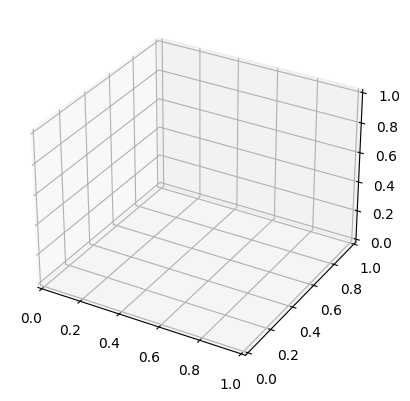

In [65]:
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt


ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('surface');


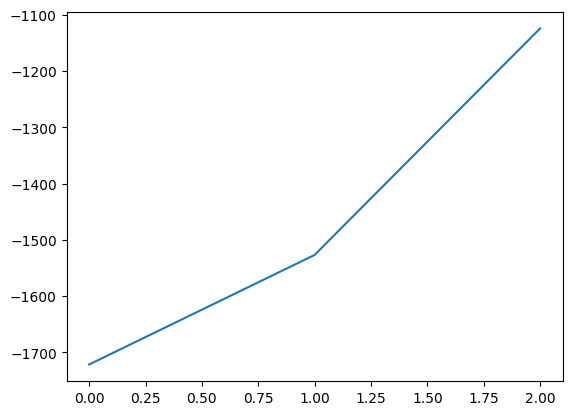

In [63]:
import matplotlib.pyplot as plt
plt.plot(costhistory)


In [10]:
probs = solver.get_probs_func( weights)(params)

In [11]:
solver.check_results(probs)

0

In [ ]:
%load_ext autoreload
%autoreload 2

In [12]:
solver.print_results(probs)

Key: 1110011011111 with probability 0.00087   | correct: False
Key: 1110011101111 with probability 0.00083   | correct: False
Key: 0010011011101 with probability 0.00083   | correct: False
Key: 1110101011100 with probability 0.00083   | correct: False
Key: 1100011011101 with probability 0.00078   | correct: False
Key: 0011111011111 with probability 0.00078   | correct: False
Key: 1110010111111 with probability 0.00078   | correct: False
Key: 1110101101100 with probability 0.00077   | correct: False
Key: 0010011101101 with probability 0.00076   | correct: False
Key: 1100011101101 with probability 0.00074   | correct: False
Key: 1111001011110 with probability 0.00074   | correct: False
Key: 0011111101111 with probability 0.00074   | correct: False
Key: 1111001101110 with probability 0.00070   | correct: False
Key: 1110111011101 with probability 0.00069   | correct: False
Key: 1110100111100 with probability 0.00067   | correct: False
Key: 0011110111111 with probability 0.00067   | correct